In [1]:
import time, warnings, re
from pathlib import Path
import numpy as np
import pandas as pd
import requests
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
from IPython.display import display

# Plotting defaults and colour palette
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05, palette="muted")
plt.rcParams["figure.dpi"]    = 120
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.2f}".format)

NAVY, STEEL, CORAL, GREEN, BLACK, RED, GOLD, LIGHTBLUE, BROWN, ROSE = \
    "#1A3764", "#4682B4", "#E8735A", "#27AE60", "#000000", \
    "#E74C3C", "#F1C40F", "#A2D2FF", "#8B4513", "#FF69B4"
PALETTE = [NAVY, STEEL, CORAL, GREEN, BLACK, RED, GOLD, LIGHTBLUE, BROWN, ROSE]

In [8]:
# Do you want to download new datasets from the API? 
# Set to True if you want to download new datasets, or False if you want to use the existing CSV files in the data folder.
download_new_datasets = False
if download_new_datasets:
    # AI adoption API link
    AI_adoption_link = "https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/isoc_eb_ai/1.0?compress=false&format=csvdata&formatVersion=2.0&lang=en&labels=name"
    AI_by_NACE_link = "https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/isoc_eb_ain2/1.0?compress=false&format=csvdata&formatVersion=2.0&lang=en&labels=name"

    # Downloading the datasets and saving them as CSV files in the data folder
    AI_adoption_response = requests.get(AI_adoption_link)
    AI_by_NACE_response = requests.get(AI_by_NACE_link)

    with open("data/AI_adoption_in_EU_enterprises.csv", "wb") as f:
        f.write(AI_adoption_response.content)
    with open("data/AI_by_NACE.csv", "wb") as f:
        f.write(AI_by_NACE_response.content)

    # Loading the datasets into pandas DataFrames
    AI_adoption_df = pd.read_csv("data/AI_adoption_in_EU_enterprises.csv", skiprows=1)
    AI_by_NACE_df = pd.read_csv("data/AI_by_NACE.csv", skiprows=1)

print("AI Adoption in EU Enterprises Dataset:")
display(AI_adoption_df.head())
print("\nAI Adoption by NACE Dataset:")
display(AI_by_NACE_df.head())

AI Adoption in EU Enterprises Dataset:


,dataflow,ESTAT:ISOC_EB_AI(1.0),Artificial intelligence by size class of enterprise,A,Annual,0-9,From 0 to 9 persons employed,C10-S951_X_K,"All activities (except agriculture, forestry and fishing, and mining and quarrying), without financial sector",E_AIX_CC1SIX_DA,"Enterprises perform data analytics, but don't use AI technologies and don't buy sophisticated or intermediate cloud computing services",PC_ENT,Percentage of enterprises,ES,Spain,2023,Unnamed: 16,5.74,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,dataflow,ESTAT:ISOC_EB_AI(1.0),Artificial intelligence by size class of enter...,A,Annual,0-9,From 0 to 9 persons employed,C10-S951_X_K,"All activities (except agriculture, forestry a...",E_AIX_CC1SIX_DA,"Enterprises perform data analytics, but don't ...",PC_ENT,Percentage of enterprises,ES,Spain,2024,NaN,5.66,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:ISOC_EB_AI(1.0),Artificial intelligence by size class of enter...,A,Annual,0-9,From 0 to 9 persons employed,C10-S951_X_K,"All activities (except agriculture, forestry a...",E_AIX_CC1SIX_DA,"Enterprises perform data analytics, but don't ...",PC_ENT,Percentage of enterprises,ES,Spain,2025,NaN,5.49,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:ISOC_EB_AI(1.0),Artificial intelligence by size class of enter...,A,Annual,0-9,From 0 to 9 persons employed,C10-S951_X_K,"All activities (except agriculture, forestry a...",E_AIX_CC1SIX_DA,"Enterprises perform data analytics, but don't ...",PC_ENT,Percentage of enterprises,PT,Portugal,2023,NaN,13.36,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:ISOC_EB_AI(1.0),Artificial intelligence by size class of enter...,A,Annual,0-9,From 0 to 9 persons employed,C10-S951_X_K,"All activities (except agriculture, forestry a...",E_AIX_CC1SIX_DA,"Enterprises perform data analytics, but don't ...",PC_ENT_IUSE,Percentage of enterprises where persons employ...,ES,Spain,2023,NaN,6.88,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:ISOC_EB_AI(1.0),Artificial intelligence by size class of enter...,A,Annual,0-9,From 0 to 9 persons employed,C10-S951_X_K,"All activities (except agriculture, forestry a...",E_AIX_CC1SIX_DA,"Enterprises perform data analytics, but don't ...",PC_ENT_IUSE,Percentage of enterprises where persons employ...,ES,Spain,2024,NaN,6.94,NaN,NaN,NaN,NaN,NaN



AI Adoption by NACE Dataset:


,dataflow,ESTAT:ISOC_EB_AIN2(1.0),Artificial intelligence by NACE Rev. 2 activity,A,Annual,GE10,10 persons employed or more,C,Manufacturing,E_AIX_CC1SIX_DA,"Enterprises perform data analytics, but don't use AI technologies and don't buy sophisticated or intermediate cloud computing services",PC_ENT,Percentage of enterprises,AT,Austria,2023,Unnamed: 16,8.24,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,dataflow,ESTAT:ISOC_EB_AIN2(1.0),Artificial intelligence by NACE Rev. 2 activity,A,Annual,GE10,10 persons employed or more,C,Manufacturing,E_AIX_CC1SIX_DA,"Enterprises perform data analytics, but don't ...",PC_ENT,Percentage of enterprises,AT,Austria,2025,NaN,4.98,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:ISOC_EB_AIN2(1.0),Artificial intelligence by NACE Rev. 2 activity,A,Annual,GE10,10 persons employed or more,C,Manufacturing,E_AIX_CC1SIX_DA,"Enterprises perform data analytics, but don't ...",PC_ENT,Percentage of enterprises,BA,Bosnia and Herzegovina,2023,NaN,17.89,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:ISOC_EB_AIN2(1.0),Artificial intelligence by NACE Rev. 2 activity,A,Annual,GE10,10 persons employed or more,C,Manufacturing,E_AIX_CC1SIX_DA,"Enterprises perform data analytics, but don't ...",PC_ENT,Percentage of enterprises,BA,Bosnia and Herzegovina,2025,NaN,13.24,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:ISOC_EB_AIN2(1.0),Artificial intelligence by NACE Rev. 2 activity,A,Annual,GE10,10 persons employed or more,C,Manufacturing,E_AIX_CC1SIX_DA,"Enterprises perform data analytics, but don't ...",PC_ENT,Percentage of enterprises,BE,Belgium,2023,NaN,21.08,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:ISOC_EB_AIN2(1.0),Artificial intelligence by NACE Rev. 2 activity,A,Annual,GE10,10 persons employed or more,C,Manufacturing,E_AIX_CC1SIX_DA,"Enterprises perform data analytics, but don't ...",PC_ENT,Percentage of enterprises,BE,Belgium,2025,NaN,9.21,NaN,NaN,NaN,NaN,NaN


In [3]:
# Configuration

EU27 = [
    'Belgium', 'Bulgaria', 'Czechia', 'Denmark', 'Germany', 'Estonia',
    'Ireland', 'Greece', 'Spain', 'France', 'Croatia', 'Italy', 'Cyprus',
    'Latvia', 'Lithuania', 'Luxembourg', 'Hungary', 'Malta', 'Netherlands',
    'Austria', 'Poland', 'Portugal', 'Romania', 'Slovenia', 'Slovakia',
    'Finland', 'Sweden'
]

In [4]:
# helper functions

def is_year(v):
    # check if value is a year
    try:
        return 2000 < int(v) < 2030
    except:
        return False

In [5]:
def read_estat_sheet(path, sheet_name, eu27=EU27):
    df = pd.read_excel(path, sheet_name=sheet_name, header=None)

    # find where TIME row is
    time_idx = None
    for i in range(len(df)):
        if df.iloc[i, 0] == 'TIME':
            time_idx = i
            break
    if time_idx is None:
        return pd.DataFrame(columns=['country', 'yr', 'value'])

    year_row = df.iloc[time_idx]
    years = [(j, int(v)) for j, v in enumerate(year_row) if is_year(v)]

    records = []
    for i in range(time_idx + 2, len(df)):
        country = df.iloc[i, 0]
        if not isinstance(country, str):
            continue
        country = country.strip()
        if country not in eu27:
            continue
        for j, yr in years:
            val = df.iloc[i, j] if j < df.shape[1] else np.nan
            try:
                val = float(val)
            except:
                val = np.nan
            records.append({'country': country, 'yr': yr, 'value': val})

    return pd.DataFrame(records)

In [6]:
def read_sector_eu_avg(path, sheet_name, eu27=EU27):
    df = pd.read_excel(path, sheet_name=sheet_name, header=None)

    # get sector name
    sector_name = None
    for i in range(15):
        row = df.iloc[i]
        if isinstance(row[0], str) and 'NACE' in row[0]:
            sector_name = str(row[2]).strip() if not pd.isna(row[2]) else None
            break

    # find TIME row
    time_idx = None
    for i in range(len(df)):
        if df.iloc[i, 0] == 'TIME':
            time_idx = i
            break
    if time_idx is None:
        return None, np.nan

    year_row = df.iloc[time_idx]
    years = [(j, int(v)) for j, v in enumerate(year_row) if is_year(v)]

    vals_2025 = []
    for i in range(time_idx + 2, len(df)):
        ctr = df.iloc[i, 0]
        if not isinstance(ctr, str) or ctr.strip() not in eu27:
            continue
        for j, yr in years:
            if yr == 2025:
                v = df.iloc[i, j]
                if isinstance(v, (int, float)):
                    vals_2025.append(float(v))

    avg = np.nanmean(vals_2025) if vals_2025 else np.nan
    return sector_name, avg

In [7]:
# load size data
print("loading size data...")

df_small = read_estat_sheet(file_size, 'Sheet 1')
df_small['size'] = 'Small (10-49)'
df_all = read_estat_sheet(file_size, 'Sheet 9')
df_all['size'] = 'All (10+)'
df_large = read_estat_sheet(file_size, 'Sheet 17')
df_large['size'] = 'Large (250+)'
df_size = pd.concat([df_small, df_all, df_large], ignore_index=True)

# load sector data
print("loading sector data...")

sector_map = {
    'Manufacturing': 'Sheet 1',
    'All activities': 'Sheet 5',
    'Information & Communication': 'Sheet 33',
}
dfs = []
for sector, sheet in sector_map.items():
    d = read_estat_sheet(file_sector, sheet)
    d['sector'] = sector
    dfs.append(d)
df_sector = pd.concat(dfs, ignore_index=True)

# filter to 2025
all25 = df_size[(df_size['size'] == 'All (10+)') & (df_size['yr'] == 2025)].set_index('country')['value']
small25 = df_size[(df_size['size'] == 'Small (10-49)') & (df_size['yr'] == 2025)].set_index('country')['value']
large25 = df_size[(df_size['size'] == 'Large (250+)') & (df_size['yr'] == 2025)].set_index('country')['value']

EU27_ORDER_2025 = all25.sort_values(ascending=True).index.tolist()

loading size data...


NameError: name 'file_size' is not defined

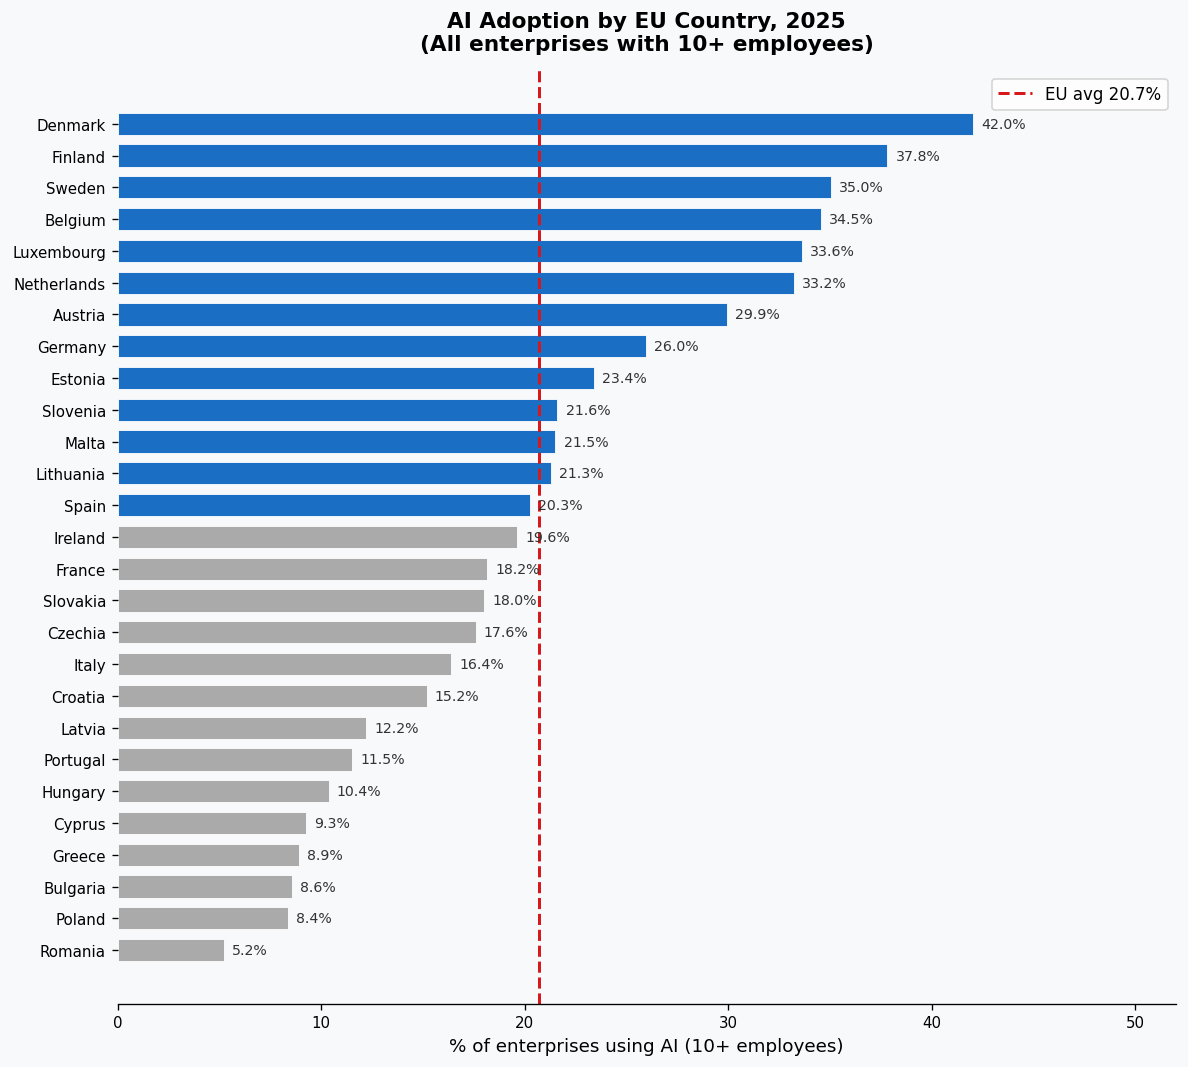

In [ ]:
# ── Chart 1 — AI adoption by country (all firms, 2025) ───────────────────────
fig, ax = plt.subplots(figsize=(10, 9), facecolor=BG)
ax.set_facecolor(BG)

sub    = all25.reindex(EU27_ORDER_2025)
colors = [C_BLUE if v >= 20 else C_GREY for v in sub]
ax.barh(sub.index, sub.values, color=colors, edgecolor='white', linewidth=0.5, height=0.7)

eu_avg = sub.mean()
ax.axvline(eu_avg, color=C_RED, lw=1.8, linestyle='--', label=f'EU avg {eu_avg:.1f}%')

for i, (country, val) in enumerate(sub.items()):
    ax.text(val + 0.4, i, f'{val:.1f}%', va='center', fontsize=8.5, color='#333333')

ax.set_xlabel('% of enterprises using AI (10+ employees)', fontsize=11)
ax.set_title('AI Adoption by EU Country, 2025\n(All enterprises with 10+ employees)',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10)
ax.set_xlim(0, 52)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='both', labelsize=9)
plt.tight_layout()
plt.show()

Building Chart 2 …


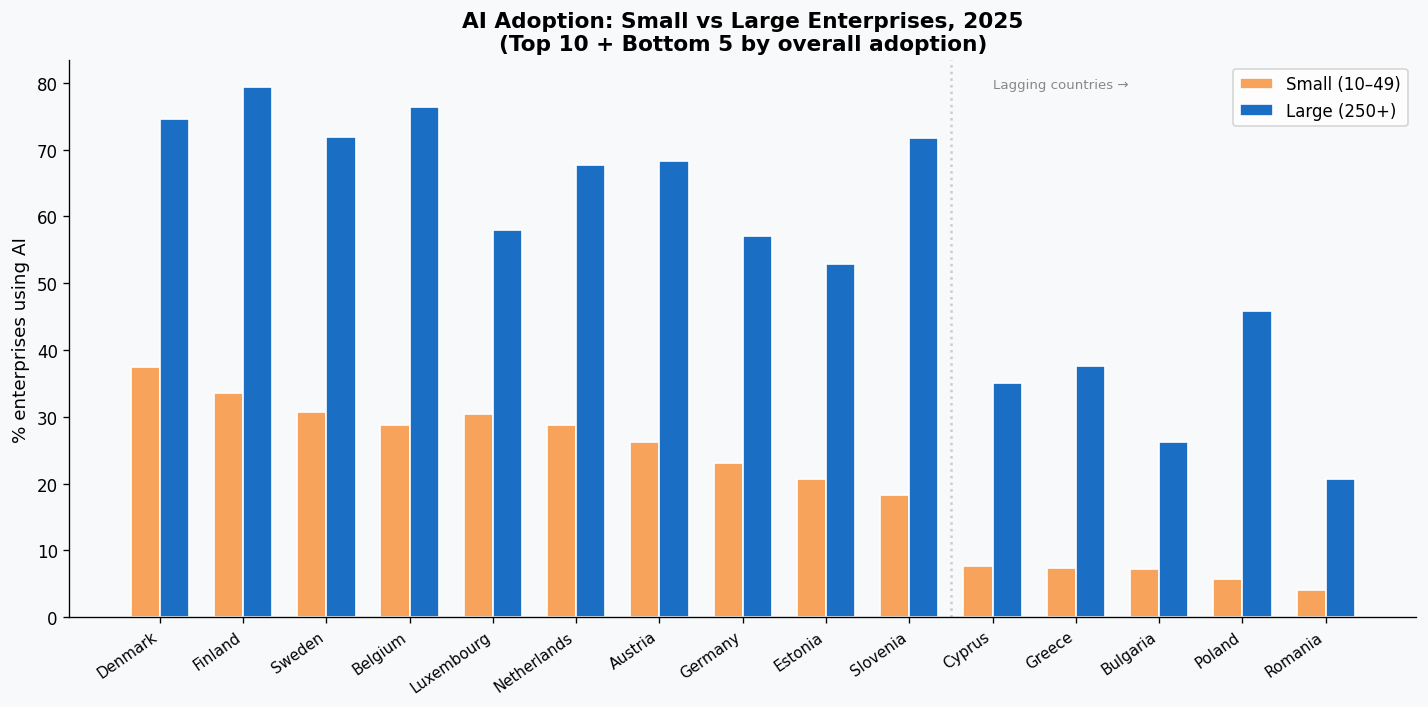

In [ ]:
# ── Chart 2 — Small vs Large: top 10 + bottom 5 countries ───────────────────
print("Building Chart 2 …")
sel = (all25.sort_values(ascending=False).head(10).index.tolist() +
       all25.sort_values(ascending=False).tail(5).index.tolist())

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
ax.set_facecolor(BG)

x, w = np.arange(len(sel)), 0.35
ax.bar(x - w/2, [small25.get(c, np.nan) for c in sel], w,
       label='Small (10–49)', color=C_ORANGE, edgecolor='white')
ax.bar(x + w/2, [large25.get(c, np.nan) for c in sel], w,
       label='Large (250+)',  color=C_BLUE,   edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(sel, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('% enterprises using AI', fontsize=11)
ax.set_title('AI Adoption: Small vs Large Enterprises, 2025\n(Top 10 + Bottom 5 by overall adoption)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axvline(9.5, color='#cccccc', lw=1.5, linestyle=':')
ax.text(10, ax.get_ylim()[1] * 0.95, 'Lagging countries →', fontsize=8, color='#888888')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

Building Chart 3 …


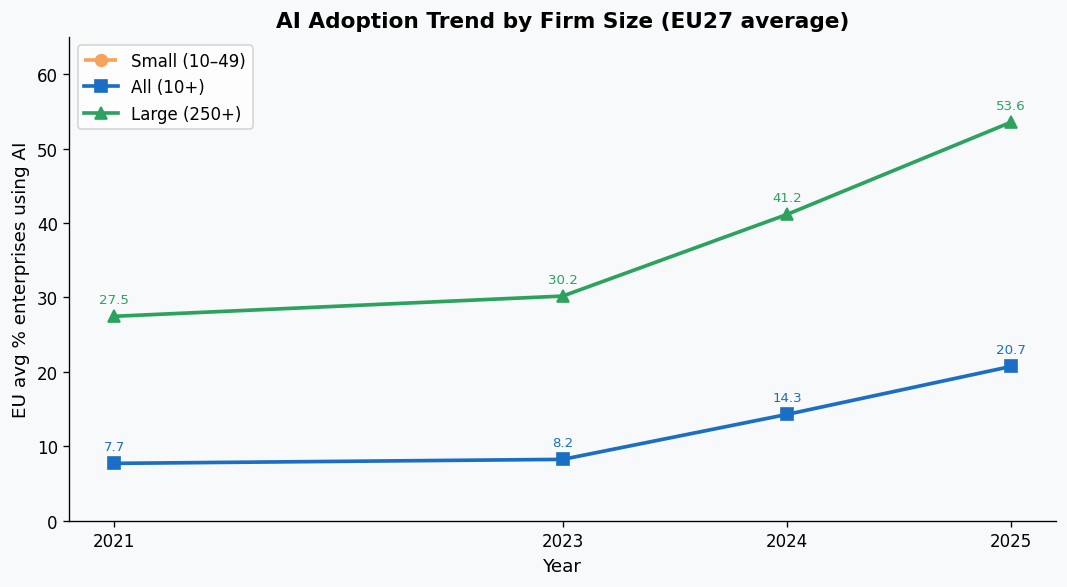

In [ ]:
# ── Chart 3 — Time trend: EU avg by size class (2021–2025) ──────────────────
print("Building Chart 3 …")
fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
ax.set_facecolor(BG)

styles = {
    'Small (10–49)': (C_ORANGE, 'o', '--'),
    'All (10+)':     (C_BLUE,   's', '-'),
    'Large (250+)':  (C_GREEN,  '^', '-'),
}
for size, (col, marker, ls) in styles.items():
    trend = df_size[df_size['size'] == size].groupby('yr')['value'].mean().sort_index()
    ax.plot(trend.index, trend.values, color=col, marker=marker, linestyle=ls,
            linewidth=2.2, markersize=7, label=size)
    for yr, val in trend.items():
        ax.annotate(f'{val:.1f}', (yr, val), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8, color=col)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('EU avg % enterprises using AI', fontsize=11)
ax.set_title('AI Adoption Trend by Firm Size (EU27 average)', fontsize=13, fontweight='bold')
ax.set_xticks([2021, 2023, 2024, 2025])
ax.legend(fontsize=10)
ax.set_ylim(0, 65)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

Building Chart 4 …


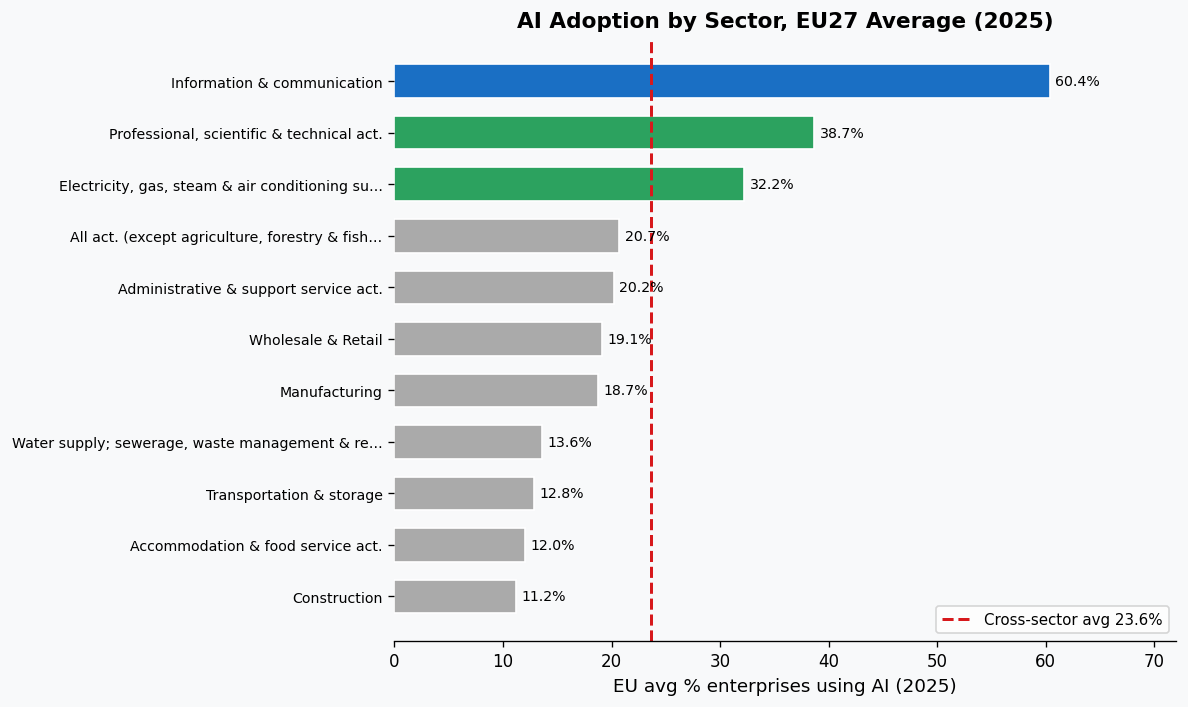

In [ ]:
# ── Chart 4 — Sector comparison (EU avg 2025) ────────────────────────────────
print("Building Chart 4 …")
xl = pd.ExcelFile(file_sector)
# Sheets containing "using at least one AI tech" for each sector (every 4th sheet)
sector_sheet_nums = [1, 5, 9, 13, 17, 21, 25, 29, 33, 41, 45]
sector_data = {}
for sn in sector_sheet_nums:
    sheet = f'Sheet {sn}'
    if sheet not in xl.sheet_names:
        continue
    name, avg = read_sector_eu_avg(file_sector, sheet)
    if name and not np.isnan(avg):
        short = (name
                 .replace('activities', 'act.')
                 .replace('and', '&')
                 .replace('Wholesale & retail trade; repair of motor vehicles & motorcycles',
                          'Wholesale & Retail'))
        if len(short) > 45:
            short = short[:45] + '…'
        sector_data[short] = avg

sector_s = pd.Series(sector_data).sort_values()

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.set_facecolor(BG)
colors_s = [C_BLUE if 'Information' in k else (C_GREEN if v >= sector_s.mean() else C_GREY)
            for k, v in sector_s.items()]
ax.barh(sector_s.index, sector_s.values, color=colors_s, edgecolor='white', height=0.65)
ax.axvline(sector_s.mean(), color=C_RED, lw=1.8, linestyle='--',
           label=f'Cross-sector avg {sector_s.mean():.1f}%')
for i, (k, v) in enumerate(sector_s.items()):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8.5)
ax.set_xlabel('EU avg % enterprises using AI (2025)', fontsize=11)
ax.set_title('AI Adoption by Sector, EU27 Average (2025)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 72)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', labelsize=8.5)
plt.tight_layout()
plt.show()

Building Chart 5 …


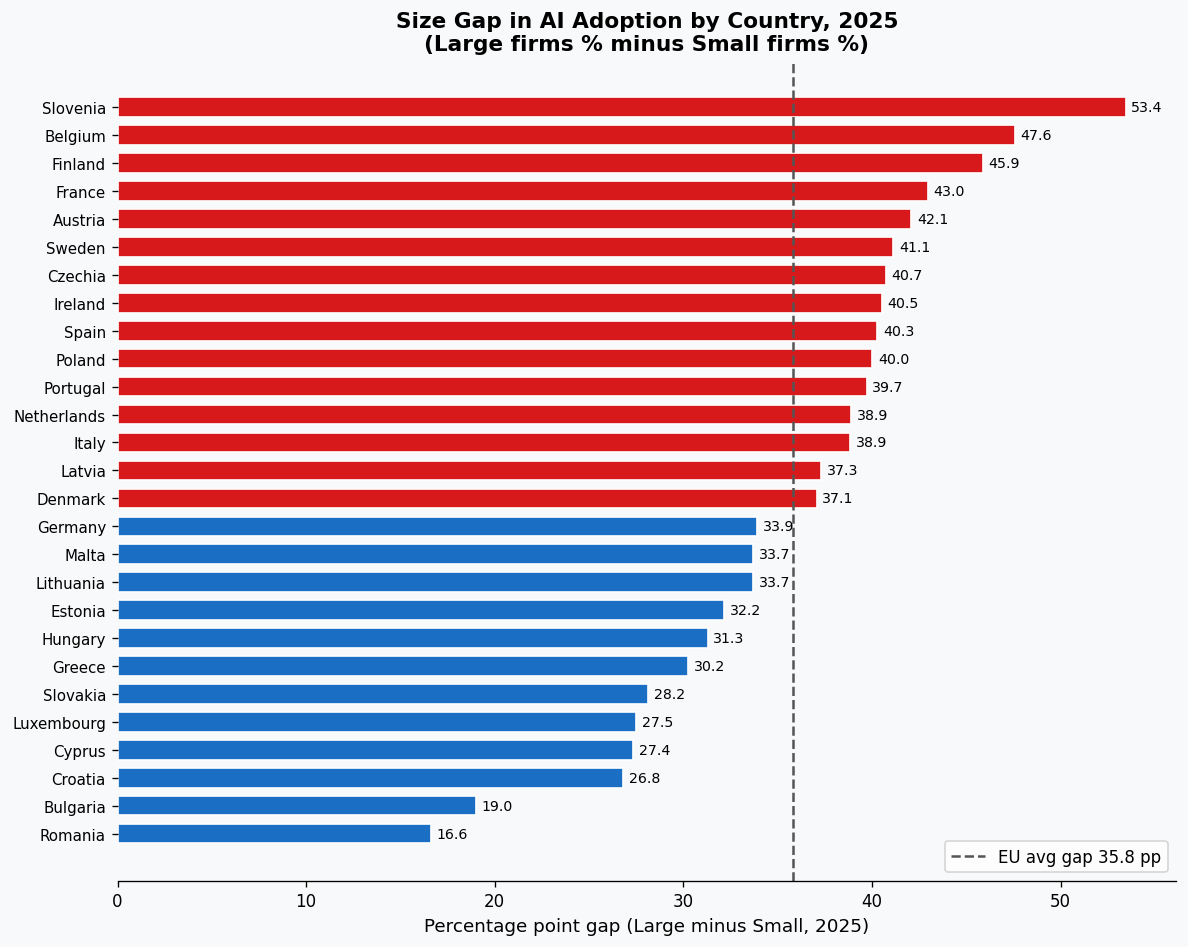

In [ ]:
# ── Chart 5 — Size gap (large minus small) per country ───────────────────────
print("Building Chart 5 …")
gap = (large25 - small25).dropna().sort_values()

fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)
ax.set_facecolor(BG)
cols_gap = [C_BLUE if v < gap.mean() else C_RED for v in gap]
ax.barh(gap.index, gap.values, color=cols_gap, edgecolor='white', height=0.7)
ax.axvline(gap.mean(), color='#555555', lw=1.5, linestyle='--',
           label=f'EU avg gap {gap.mean():.1f} pp')
for i, (k, v) in enumerate(gap.items()):
    ax.text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=8.5)
ax.set_xlabel('Percentage point gap (Large minus Small, 2025)', fontsize=11)
ax.set_title('Size Gap in AI Adoption by Country, 2025\n(Large firms % minus Small firms %)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ── Save clean CSVs ───────────────────────────────────────────────────────────
df_size.to_csv('ai_by_size.csv', index=False)
df_sector.to_csv('ai_by_sector.csv', index=False)
print("\nClean CSVs saved: ai_by_size.csv, ai_by_sector.csv")
print("\nAll done! ✓")